In [1]:
!ls -lh

total 4.0K
drwxr-xr-x 1 root root 4.0K Sep  4 13:25 sample_data


In [2]:
from google.colab import files
uploaded = files.upload()

Saving archive.zip to archive.zip


In [3]:
!ls -lh

total 23M
-rw-r--r-- 1 root root  23M Sep 14 15:48 archive.zip
drwxr-xr-x 1 root root 4.0K Sep  4 13:25 sample_data


In [5]:
import zipfile

with zipfile.ZipFile("archive.zip", "r") as zip_ref:
    zip_ref.extractall("dataset")

In [6]:
!find dataset -maxdepth 3 -type d

dataset
dataset/train
dataset/train/Open_Eyes
dataset/train/Closed_Eyes


In [7]:
import os

open_path = "dataset/train/Open_Eyes"
closed_path = "dataset/train/Closed_Eyes"

print("Open eye images:", len(os.listdir(open_path)))
print("Closed eye images:", len(os.listdir(closed_path)))

Open eye images: 2000
Closed eye images: 2000


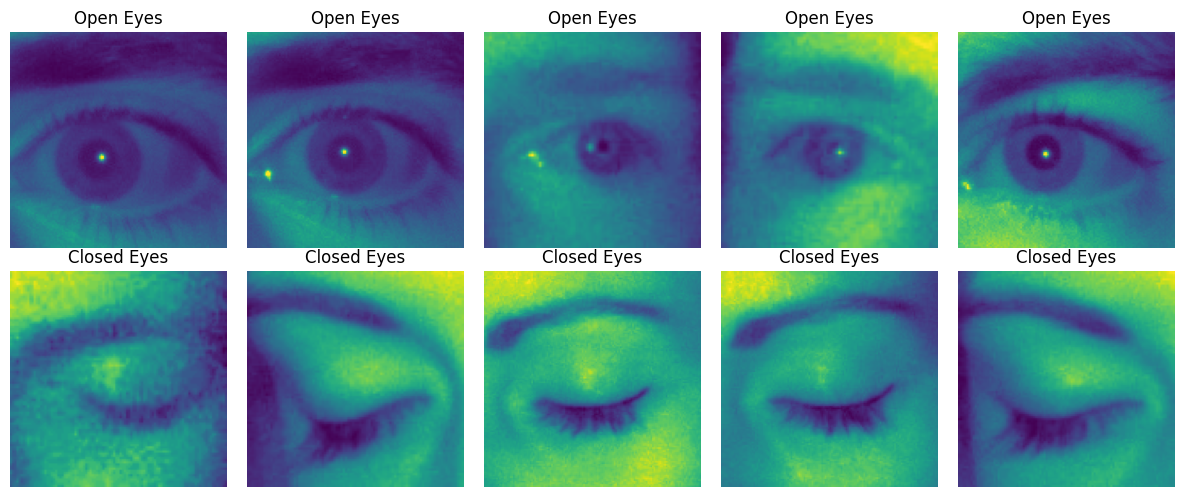

In [8]:
import matplotlib.pyplot as plt
from PIL import Image
import os

open_files = os.listdir("dataset/train/Open_Eyes")
closed_files = os.listdir("dataset/train/Closed_Eyes")

fig, axes = plt.subplots(2, 5, figsize=(12, 5))

for i in range(5):
    img = Image.open("dataset/train/Open_Eyes/" + open_files[i])
    axes[0, i].imshow(img)
    axes[0, i].set_title("Open Eyes")
    axes[0, i].axis("off")

for i in range(5):
    img = Image.open("dataset/train/Closed_Eyes/" + closed_files[i])
    axes[1, i].imshow(img)
    axes[1, i].set_title("Closed Eyes")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [9]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [18]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_data = datagen.flow_from_directory(
    "dataset/train",
    target_size=(128, 128),
    batch_size=32,
    class_mode="binary",
    subset="training"
)

validation_data = datagen.flow_from_directory(
    "dataset/train",
    target_size=(128, 128),
    batch_size=32,
    class_mode="binary",
    subset="validation",
    shuffle=False
)


Found 3200 images belonging to 2 classes.
Found 800 images belonging to 2 classes.


In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential([

    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 128, 3)),
    MaxPooling2D(2, 2),

    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(2, 2),

    Flatten(),

    Dense(128, activation='relu'),
    Dropout(0.5),

    Dense(1, activation='sigmoid')
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [12]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")

Model compiled successfully!


In [13]:
print(train_data.class_indices)

{'Closed_Eyes': 0, 'Open_Eyes': 1}


In [14]:
history = model.fit(
    train_data,
    validation_data=validation_data,
    epochs=10
)

Epoch 1/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 98s 958ms/step - accuracy: 0.8938 - loss: 0.2338 - val_accuracy: 0.9438 - val_loss: 0.2559
Epoch 2/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 92s 920ms/step - accuracy: 0.9787 - loss: 0.0649 - val_accuracy: 0.6187 - val_loss: 0.9096
Epoch 3/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 86s 861ms/step - accuracy: 0.9884 - loss: 0.0355 - val_accuracy: 0.9887 - val_loss: 0.0510
Epoch 4/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 83s 834ms/step - accuracy: 0.9912 - loss: 0.0321 - val_accuracy: 0.8313 - val_loss: 0.4932
Epoch 5/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 91s 912ms/step - accuracy: 0.9922 - loss: 0.0291 - val_accuracy: 0.8388 - val_loss: 0.6721
Epoch 6/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 84s 839ms/step - accuracy: 0.9931 - loss: 0.0249 - val_accuracy: 0.9262 - val_loss: 0.2877
Epoch 7/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 73s 735ms/step - accuracy: 0.9962 - loss: 0.0095 - val_accuracy: 0.9450 - val_loss: 0.3137
Epoch 8/10
100/100 ━━━━━━━━━━━━━━━━━━━━ 73s 730ms/step - accuracy: 0.9981 - loss: 0

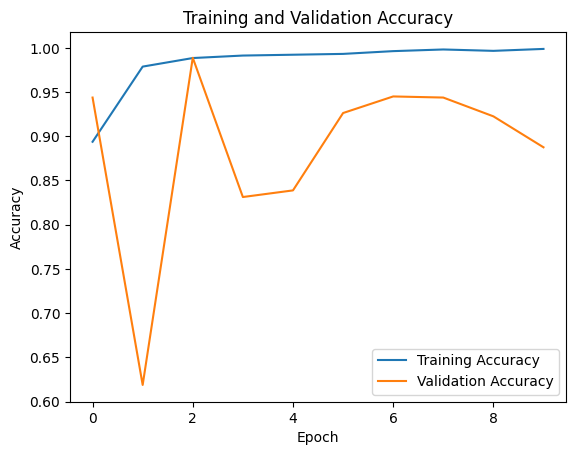

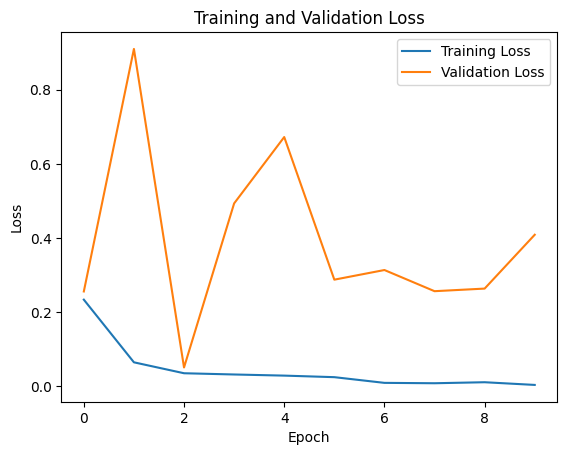

In [15]:
import matplotlib.pyplot as plt

# Accuracy graph
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()
plt.show()


# Loss graph
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()

In [16]:
loss, accuracy = model.evaluate(validation_data)

print("Validation Accuracy:", accuracy)
print("Validation Loss:", loss)

25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 176ms/step - accuracy: 0.8875 - loss: 0.4088
Validation Accuracy: 0.887499988079071
Validation Loss: 0.4087744653224945


25/25 ━━━━━━━━━━━━━━━━━━━━ 4s 170ms/step


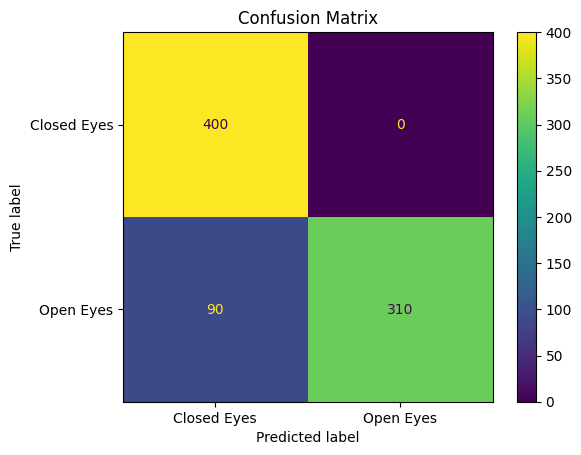

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Get true labels and predictions
validation_data.reset()

predictions = model.predict(validation_data)
predicted_classes = (predictions > 0.5).astype(int).flatten()

true_classes = validation_data.classes

# Create confusion matrix
cm = confusion_matrix(true_classes, predicted_classes)

# Display confusion matrix
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Closed Eyes', 'Open Eyes']
)

disp.plot()
plt.title('Confusion Matrix')
plt.show()

In [20]:
from sklearn.metrics import classification_report

print(classification_report(
    true_classes,
    predicted_classes,
    target_names=['Closed Eyes', 'Open Eyes']
))

              precision    recall  f1-score   support

 Closed Eyes       0.82      1.00      0.90       400
   Open Eyes       1.00      0.78      0.87       400

    accuracy                           0.89       800
   macro avg       0.91      0.89      0.89       800
weighted avg       0.91      0.89      0.89       800



In [21]:
model.save("drowsiness_cnn.keras")

print("Model saved successfully!")

Model saved successfully!


In [23]:
import cv2

print(cv2.__version__)
print(cv2.data.haarcascades)

5.0.0
/usr/local/lib/python3.13/dist-packages/cv2/data/


In [25]:
!pip uninstall -y opencv-python opencv-python-headless opencv-contrib-python
!pip install opencv-python

Found existing installation: opencv-python 5.0.0.93
Uninstalling opencv-python-5.0.0.93:
  Successfully uninstalled opencv-python-5.0.0.93
Found existing installation: opencv-python-headless 5.0.0.93
Uninstalling opencv-python-headless-5.0.0.93:
  Successfully uninstalled opencv-python-headless-5.0.0.93
Found existing installation: opencv-contrib-python 4.14.0.94
Uninstalling opencv-contrib-python-4.14.0.94:
  Successfully uninstalled opencv-contrib-python-4.14.0.94
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 73.8/73.8 MB 11.1 MB/s eta 0:00:00


In [1]:
import cv2

print(cv2.__version__)
print(hasattr(cv2, "CascadeClassifier"))

4.10.0
True


In [2]:
!pip uninstall -y opencv-python opencv-python-headless opencv-contrib-python
!pip install opencv-python==4.10.0.84

Found existing installation: opencv-python 5.0.0.93
Uninstalling opencv-python-5.0.0.93:
  Successfully uninstalled opencv-python-5.0.0.93
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.5/62.5 MB 10.9 MB/s eta 0:00:00


In [2]:
import cv2

eye_cascade = cv2.CascadeClassifier(
    cv2.data.haarcascades + "haarcascade_eye.xml"
)

print("Eye detector loaded successfully!")

Eye detector loaded successfully!


In [3]:
from tensorflow.keras.models import load_model

model = load_model("drowsiness_cnn.keras")

print("CNN model loaded successfully!")

CNN model loaded successfully!


In [4]:
from google.colab import files

uploaded = files.upload()

Saving daraset.mp4 to daraset.mp4


In [5]:
import cv2

video_path = "daraset.mp4"

cap = cv2.VideoCapture(video_path)

if cap.isOpened():
    print("Video opened successfully!")
else:
    print("Could not open the video.")

fps = cap.get(cv2.CAP_PROP_FPS)
frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

print("FPS:", fps)
print("Total frames:", frame_count)
print("Approximate duration:", frame_count / fps, "seconds")

Video opened successfully!
FPS: 23.976023976023978
Total frames: 4673
Approximate duration: 194.90304166666667 seconds


In [6]:
import cv2

video_path = "daraset.mp4"

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)

# Process first 10 seconds
max_frames = int(fps * 10)

count = 0
detected_frames = 0

while count < max_frames:
    ret, frame = cap.read()

    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    eyes = eye_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )

    if len(eyes) > 0:
        detected_frames += 1

    count += 1

cap.release()

print("Frames processed:", count)
print("Frames with eyes detected:", detected_frames)

Frames processed: 239
Frames with eyes detected: 239


In [7]:
import cv2
import numpy as np

video_path = "daraset.mp4"

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
max_frames = int(fps * 10)   # first 10 seconds

open_count = 0
closed_count = 0
frames_with_prediction = 0

while frames_with_prediction < max_frames:

    ret, frame = cap.read()

    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    eyes = eye_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )

    if len(eyes) > 0:

        # Take the largest detected eye
        eye = max(eyes, key=lambda e: e[2] * e[3])

        x, y, w, h = eye

        eye_img = frame[y:y+h, x:x+w]

        # Prepare image for CNN
        eye_img = cv2.resize(eye_img, (128, 128))
        eye_img = eye_img.astype("float32") / 255.0
        eye_img = np.expand_dims(eye_img, axis=0)

        # CNN prediction
        prediction = model.predict(eye_img, verbose=0)[0][0]

        if prediction >= 0.5:
            open_count += 1
        else:
            closed_count += 1

        frames_with_prediction += 1

cap.release()

print("Frames analyzed:", frames_with_prediction)
print("Open-eye predictions:", open_count)
print("Closed-eye predictions:", closed_count)

Frames analyzed: 239
Open-eye predictions: 212
Closed-eye predictions: 27


In [9]:
import cv2
import numpy as np

video_path = "daraset.mp4"

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
max_frames = int(fps * 10)  # only first 10 seconds

eye_images = []
frame_numbers = []

count = 0

while count < max_frames:

    ret, frame = cap.read()

    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    eyes = eye_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )

    if len(eyes) > 0:

        eye = max(eyes, key=lambda e: e[2] * e[3])

        x, y, w, h = eye

        eye_img = frame[y:y+h, x:x+w]

        eye_img = cv2.resize(eye_img, (128, 128))
        eye_img = eye_img.astype("float32") / 255.0

        eye_images.append(eye_img)
        frame_numbers.append(count)

    count += 1

cap.release()

# Convert all eye images into one batch
eye_images = np.array(eye_images)

print("Frames processed:", count)
print("Eye images collected:", len(eye_images))

# Predict all images together
predictions = model.predict(eye_images, verbose=0)

open_count = np.sum(predictions >= 0.5)
closed_count = np.sum(predictions < 0.5)

print("Open-eye predictions:", open_count)
print("Closed-eye predictions:", closed_count)

Frames processed: 239
Eye images collected: 239
Open-eye predictions: 212
Closed-eye predictions: 27


In [10]:
import cv2
import numpy as np

video_path = "daraset.mp4"
output_path = "drowsiness_result.mp4"

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Process only first 10 seconds
max_frames = int(fps * 10)

fourcc = cv2.VideoWriter_fourcc(*"mp4v")
out = cv2.VideoWriter(
    output_path,
    fourcc,
    fps,
    (width, height)
)

closed_counter = 0

# About 1 second of continuous closed-eye detection
warning_threshold = int(fps)

frame_number = 0

while frame_number < max_frames:

    ret, frame = cap.read()

    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    eyes = eye_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )

    state = "No eyes detected"

    if len(eyes) > 0:

        x, y, w, h = max(eyes, key=lambda e: e[2] * e[3])

        eye_img = frame[y:y+h, x:x+w]

        eye_img = cv2.resize(eye_img, (128, 128))
        eye_img = eye_img.astype("float32") / 255.0
        eye_img = np.expand_dims(eye_img, axis=0)

        prediction = model.predict(eye_img, verbose=0)[0][0]

        if prediction >= 0.5:
            state = "OPEN EYES"
            closed_counter = 0
        else:
            state = "CLOSED EYES"
            closed_counter += 1

        # Draw eye rectangle
        cv2.rectangle(
            frame,
            (x, y),
            (x+w, y+h),
            (255, 255, 255),
            2
        )

    # Drowsiness warning
    if closed_counter >= warning_threshold:
        warning = "DROWSINESS ALERT!"
    else:
        warning = "ALERT"

    # Display results
    cv2.putText(
        frame,
        state,
        (30, 50),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (255, 255, 255),
        2
    )

    cv2.putText(
        frame,
        warning,
        (30, 95),
        cv2.FONT_HERSHEY_SIMPLEX,
        1,
        (255, 255, 255),
        2
    )

    out.write(frame)

    frame_number += 1

cap.release()
out.release()

print("Processing completed!")
print("Output video:", output_path)

Processing completed!
Output video: drowsiness_result.mp4


In [11]:
from google.colab import files

files.download("drowsiness_result.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [12]:
import cv2
import numpy as np

cap = cv2.VideoCapture("daraset.mp4")

fps = cap.get(cv2.CAP_PROP_FPS)
max_frames = int(fps * 10)

frame_number = 0

while frame_number < max_frames:

    ret, frame = cap.read()

    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    eyes = eye_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )

    if len(eyes) > 0:

        x, y, w, h = max(eyes, key=lambda e: e[2] * e[3])

        eye = frame[y:y+h, x:x+w]

        eye = cv2.resize(eye, (128, 128))
        eye = eye.astype("float32") / 255.0
        eye = np.expand_dims(eye, axis=0)

        prediction = model.predict(eye, verbose=0)[0][0]

        if frame_number % 10 == 0:
            if prediction >= 0.5:
                print("Frame", frame_number, "→ OPEN")
            else:
                print("Frame", frame_number, "→ CLOSED")

    frame_number += 1

cap.release()

Frame 0 → OPEN
Frame 10 → OPEN
Frame 20 → OPEN
Frame 30 → OPEN
Frame 40 → OPEN
Frame 50 → OPEN
Frame 60 → OPEN
Frame 70 → OPEN
Frame 80 → OPEN
Frame 90 → OPEN
Frame 100 → OPEN
Frame 110 → OPEN
Frame 120 → OPEN
Frame 130 → OPEN
Frame 140 → OPEN
Frame 150 → CLOSED
Frame 160 → OPEN
Frame 170 → OPEN
Frame 180 → OPEN
Frame 190 → OPEN
Frame 200 → CLOSED
Frame 210 → OPEN
Frame 220 → CLOSED
Frame 230 → OPEN


In [13]:
import cv2
import numpy as np

video_path = "daraset.mp4"
output_path = "final_drowsiness_demo.mp4"

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

max_frames = int(fps * 10)

fourcc = cv2.VideoWriter_fourcc(*"mp4v")

out = cv2.VideoWriter(
    output_path,
    fourcc,
    fps,
    (width, height)
)

closed_counter = 0

# About 0.4 second of continuous closed-eye detection
warning_threshold = int(fps * 0.4)

frame_number = 0

while frame_number < max_frames:

    ret, frame = cap.read()

    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    eyes = eye_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )

    state = "NO EYES DETECTED"

    if len(eyes) > 0:

        x, y, w, h = max(eyes, key=lambda e: e[2] * e[3])

        eye_img = frame[y:y+h, x:x+w]

        eye_img = cv2.resize(eye_img, (128, 128))
        eye_img = eye_img.astype("float32") / 255.0
        eye_img = np.expand_dims(eye_img, axis=0)

        prediction = model.predict(
            eye_img,
            verbose=0
        )[0][0]

        # Draw eye box
        cv2.rectangle(
            frame,
            (x, y),
            (x+w, y+h),
            (0, 255, 0),
            4
        )

        if prediction >= 0.5:

            state = "OPEN EYES"
            closed_counter = 0

        else:

            state = "CLOSED EYES"
            closed_counter += 1

    # Determine status
    if closed_counter >= warning_threshold:
        status = "DROWSINESS ALERT!"
    elif state == "CLOSED EYES":
        status = "EYES CLOSED"
    else:
        status = "ALERT - DRIVER AWAKE"

    # Large title
    cv2.putText(
        frame,
        "DRIVER DROWSINESS DETECTION",
        (30, 60),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.5,
        (255, 255, 255),
        4
    )

    # Eye state
    cv2.putText(
        frame,
        state,
        (30, 120),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.4,
        (255, 255, 255),
        4
    )

    # Status
    cv2.putText(
        frame,
        status,
        (30, 180),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.3,
        (255, 255, 255),
        4
    )

    out.write(frame)

    frame_number += 1

cap.release()
out.release()

print("Final demo created successfully!")
print("File:", output_path)

Final demo created successfully!
File: final_drowsiness_demo.mp4


In [14]:
from google.colab import files

files.download("final_drowsiness_demo.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [15]:
import cv2
import numpy as np

cap = cv2.VideoCapture("daraset.mp4")

fps = cap.get(cv2.CAP_PROP_FPS)

max_frames = int(fps * 30)   # first 30 seconds
skip = 5

current_closed = 0
longest_closed = 0

frame_number = 0

while frame_number < max_frames:

    ret, frame = cap.read()

    if not ret:
        break

    # Process only every 5th frame
    if frame_number % skip != 0:
        frame_number += 1
        continue

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    eyes = eye_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )

    if len(eyes) > 0:

        x, y, w, h = max(eyes, key=lambda e: e[2] * e[3])

        eye = frame[y:y+h, x:x+w]

        eye = cv2.resize(eye, (128, 128))
        eye = eye.astype("float32") / 255.0
        eye = np.expand_dims(eye, axis=0)

        prediction = model.predict(eye, verbose=0)[0][0]

        if prediction < 0.5:
            current_closed += 1
            longest_closed = max(longest_closed, current_closed)
        else:
            current_closed = 0

    frame_number += 1

cap.release()

print("Longest consecutive closed predictions:", longest_closed)
print("Frames sampled:", frame_number // skip)
print("Approximate closed-eye duration:",
      (longest_closed * skip) / fps,
      "seconds")

Longest consecutive closed predictions: 9
Frames sampled: 143
Approximate closed-eye duration: 1.8768749999999998 seconds


In [16]:
import cv2
import numpy as np

video_path = "daraset.mp4"
output_path = "final_drowsiness_demo.mp4"

cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)
width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# First 30 seconds
max_frames = int(fps * 30)

fourcc = cv2.VideoWriter_fourcc(*"mp4v")

out = cv2.VideoWriter(
    output_path,
    fourcc,
    fps,
    (width, height)
)

closed_start_frame = None
alert_triggered = False

frame_number = 0

while frame_number < max_frames:

    ret, frame = cap.read()

    if not ret:
        break

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    eyes = eye_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(30, 30)
    )

    state = "NO EYES DETECTED"
    closed_duration = 0

    if len(eyes) > 0:

        x, y, w, h = max(
            eyes,
            key=lambda e: e[2] * e[3]
        )

        eye_img = frame[y:y+h, x:x+w]

        eye_img = cv2.resize(
            eye_img,
            (128, 128)
        )

        eye_img = eye_img.astype("float32") / 255.0
        eye_img = np.expand_dims(
            eye_img,
            axis=0
        )

        prediction = model.predict(
            eye_img,
            verbose=0
        )[0][0]

        # Draw eye box
        cv2.rectangle(
            frame,
            (x, y),
            (x+w, y+h),
            (0, 255, 0),
            4
        )

        if prediction < 0.5:

            state = "CLOSED EYES"

            if closed_start_frame is None:
                closed_start_frame = frame_number

            closed_duration = (
                frame_number - closed_start_frame
            ) / fps

        else:

            state = "OPEN EYES"
            closed_start_frame = None
            alert_triggered = False

    # Alert logic
    if closed_duration >= 1.0:

        status = "DROWSINESS ALERT!"
        alert_triggered = True

    elif state == "CLOSED EYES":

        status = "EYES CLOSED"

    elif state == "OPEN EYES":

        status = "DRIVER ALERT"

    else:

        status = "NO EYE DETECTED"

    # Title
    cv2.putText(
        frame,
        "DRIVER DROWSINESS DETECTION",
        (30, 60),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.5,
        (255, 255, 255),
        4
    )

    # Eye state
    cv2.putText(
        frame,
        state,
        (30, 120),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.4,
        (255, 255, 255),
        4
    )

    # Status
    cv2.putText(
        frame,
        status,
        (30, 180),
        cv2.FONT_HERSHEY_SIMPLEX,
        1.3,
        (255, 255, 255),
        4
    )

    # Closed duration
    if state == "CLOSED EYES":

        cv2.putText(
            frame,
            f"Closed: {closed_duration:.2f} sec",
            (30, 240),
            cv2.FONT_HERSHEY_SIMPLEX,
            1.2,
            (255, 255, 255),
            3
        )

    out.write(frame)

    frame_number += 1

cap.release()
out.release()

print("Final video created successfully!")
print("Output:", output_path)

Final video created successfully!
Output: final_drowsiness_demo.mp4


In [17]:
from google.colab import files

files.download("final_drowsiness_demo.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [18]:
import cv2
import numpy as np

input_video = "daraset.mp4"
output_video = "final_demo_small.mp4"

cap = cv2.VideoCapture(input_video)

fps = cap.get(cv2.CAP_PROP_FPS)

# Output settings
out_width = 640
out_height = 360
out_fps = fps / 2

fourcc = cv2.VideoWriter_fourcc(*"mp4v")

out = cv2.VideoWriter(
    output_video,
    fourcc,
    out_fps,
    (out_width, out_height)
)

# Only first 10 seconds
max_frames = int(fps * 10)

closed_count = 0
frame_number = 0

while frame_number < max_frames:

    ret, frame = cap.read()

    if not ret:
        break

    # Process every 2nd frame
    if frame_number % 2 != 0:
        frame_number += 1
        continue

    # Resize frame BEFORE eye detection
    frame = cv2.resize(
        frame,
        (out_width, out_height)
    )

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    eyes = eye_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(20, 20)
    )

    state = "NO EYES"

    if len(eyes) > 0:

        x, y, w, h = max(
            eyes,
            key=lambda e: e[2] * e[3]
        )

        eye = frame[y:y+h, x:x+w]

        eye = cv2.resize(
            eye,
            (128, 128)
        )

        eye = eye.astype("float32") / 255.0
        eye = np.expand_dims(eye, axis=0)

        prediction = model.predict(
            eye,
            verbose=0
        )[0][0]

        if prediction >= 0.5:
            state = "OPEN EYES"
            closed_count = 0
        else:
            state = "CLOSED EYES"
            closed_count += 1

        # Eye box
        cv2.rectangle(
            frame,
            (x, y),
            (x+w, y+h),
            (0, 255, 0),
            3
        )

    # Alert after several consecutive closed predictions
    if closed_count >= 5:
        status = "DROWSINESS ALERT!"
    elif state == "CLOSED EYES":
        status = "EYES CLOSED"
    else:
        status = "DRIVER ALERT"

    # Add text
    cv2.putText(
        frame,
        "DRIVER DROWSINESS DETECTION",
        (15, 35),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 255, 255),
        2
    )

    cv2.putText(
        frame,
        state,
        (15, 70),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 255, 255),
        2
    )

    cv2.putText(
        frame,
        status,
        (15, 105),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 255, 255),
        2
    )

    out.write(frame)

    frame_number += 1

cap.release()
out.release()

print("DONE!")
print("Output file:", output_video)

DONE!
Output file: final_demo_small.mp4


In [19]:
from google.colab import files

files.download("final_demo_small.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [20]:
import cv2
import numpy as np

input_video = "daraset.mp4"
output_video = "final_demo_30sec.mp4"

cap = cv2.VideoCapture(input_video)

fps = cap.get(cv2.CAP_PROP_FPS)

# Output settings — same as the working version
out_width = 640
out_height = 360
out_fps = fps / 2

fourcc = cv2.VideoWriter_fourcc(*"mp4v")

out = cv2.VideoWriter(
    output_video,
    fourcc,
    out_fps,
    (out_width, out_height)
)

# Process first 30 seconds
max_frames = int(fps * 30)

closed_count = 0
frame_number = 0

while frame_number < max_frames:

    ret, frame = cap.read()

    if not ret:
        break

    # Process every 2nd frame
    if frame_number % 2 != 0:
        frame_number += 1
        continue

    # Resize frame
    frame = cv2.resize(
        frame,
        (out_width, out_height)
    )

    gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)

    eyes = eye_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5,
        minSize=(20, 20)
    )

    state = "NO EYES"

    if len(eyes) > 0:

        x, y, w, h = max(
            eyes,
            key=lambda e: e[2] * e[3]
        )

        eye = frame[y:y+h, x:x+w]

        eye = cv2.resize(
            eye,
            (128, 128)
        )

        eye = eye.astype("float32") / 255.0
        eye = np.expand_dims(eye, axis=0)

        prediction = model.predict(
            eye,
            verbose=0
        )[0][0]

        if prediction >= 0.5:
            state = "OPEN EYES"
            closed_count = 0
        else:
            state = "CLOSED EYES"
            closed_count += 1

        # Draw eye detection box
        cv2.rectangle(
            frame,
            (x, y),
            (x+w, y+h),
            (0, 255, 0),
            3
        )

    # Drowsiness status
    if closed_count >= 5:
        status = "DROWSINESS ALERT!"
    elif state == "CLOSED EYES":
        status = "EYES CLOSED"
    else:
        status = "DRIVER ALERT"

    # Title
    cv2.putText(
        frame,
        "DRIVER DROWSINESS DETECTION",
        (15, 35),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 255, 255),
        2
    )

    # Eye state
    cv2.putText(
        frame,
        state,
        (15, 70),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 255, 255),
        2
    )

    # Status
    cv2.putText(
        frame,
        status,
        (15, 105),
        cv2.FONT_HERSHEY_SIMPLEX,
        0.8,
        (255, 255, 255),
        2
    )

    out.write(frame)

    frame_number += 1

cap.release()
out.release()

print("DONE!")
print("Output file:", output_video)

DONE!
Output file: final_demo_30sec.mp4


In [21]:
from google.colab import files

files.download("final_demo_30sec.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>